# Exploratory Data Analysis

In [51]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [52]:
data_dir = Path("../data/train")
files = list(data_dir.glob("*.csv"))

dfs = {file.stem: pd.read_csv(file) for file in files}

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
df = dfs["input_2023_w01"]
df

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.09,0.39,322.40,238.24,21,63.259998,-0.22
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.04,0.61,200.89,236.05,21,63.259998,-0.22
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.93,0.12,0.73,147.55,240.60,21,63.259998,-0.22
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.35,36.92,0.23,0.81,131.40,244.25,21,63.259998,-0.22
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.37,36.90,0.35,0.82,123.26,244.25,21,63.259998,-0.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285709,2023091100,3987,True,42489,29,left,87,Stefon Diggs,6-0,191,...,Targeted Receiver,74.34,14.72,4.32,5.91,294.17,337.15,11,73.870003,11.48
285710,2023091100,3987,True,42489,30,left,87,Stefon Diggs,6-0,191,...,Targeted Receiver,74.00,14.88,3.47,6.67,297.89,4.89,11,73.870003,11.48
285711,2023091100,3987,True,42489,31,left,87,Stefon Diggs,6-0,191,...,Targeted Receiver,73.74,15.03,2.73,6.85,302.45,37.86,11,73.870003,11.48
285712,2023091100,3987,True,42489,32,left,87,Stefon Diggs,6-0,191,...,Targeted Receiver,73.56,15.16,1.94,6.85,308.57,51.94,11,73.870003,11.48


In [ ]:
df = dfs["input_2023_w01"]
game_df = df[(df["game_id"] == 2023090700)]
print(game_df["play_id"].unique())
play_df = game_df[(game_df["play_id"] == 1741)]

[ 101  194  219  361  436  461  530  621  713  736  877  902 1001 1069
 1154 1201 1300 1422 1494 1563 1588 1618 1679 1711 1741 1812 1837 1869
 1940 2118 2141 2186 2261 2306 2364 2435 2487 2510 2613 2638 2825 2906
 2936 2959 3032 3089 3114 3185 3233 3324 3461 3486 3566 3674 3912 3971
 3994 4041]


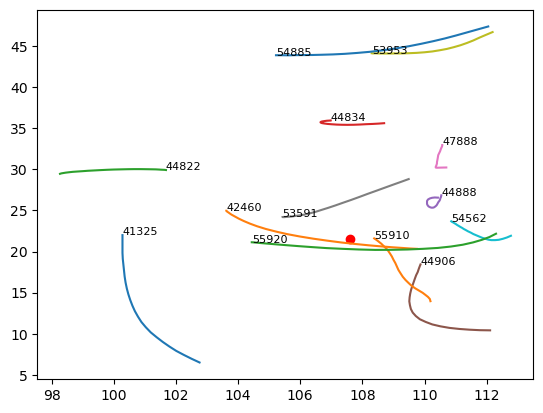

In [ ]:
for player, group in play_df.groupby("nfl_id"):
    plt.plot(group["x"], group["y"], label=player)
    plt.text(group["x"].iloc[0], group["y"].iloc[0], player, fontsize=8)
plt.scatter(
    play_df["ball_land_x"].iloc[-1], play_df["ball_land_y"].iloc[-1], color="red"
)

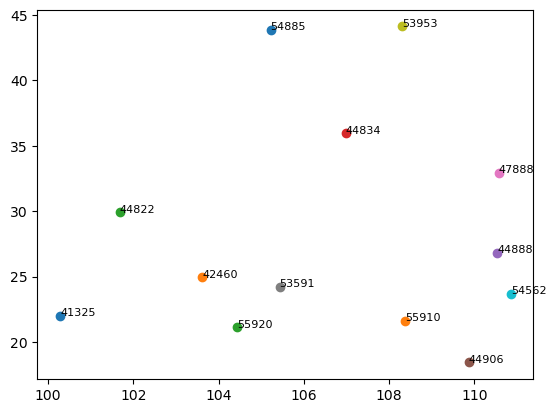

In [ ]:
for player, group in play_df[play_df["frame_id"] == 1].groupby("nfl_id"):
    plt.scatter(group["x"], group["y"], label=player)
    plt.text(group["x"].iloc[0], group["y"].iloc[0], player, fontsize=8)

In [ ]:
output_df = dfs["output_2023_w01"]
game_df = output_df[(output_df["game_id"] == 2023090700)]
print(game_df["play_id"].unique())
play_df = game_df[(game_df["play_id"] == 1741)]
play_df

[ 101  194  219  361  436  461  530  621  713  736  877  902 1001 1069
 1154 1201 1300 1422 1494 1563 1588 1618 1679 1711 1741 1812 1837 1869
 1940 2118 2141 2186 2261 2306 2364 2435 2487 2510 2613 2638 2825 2906
 2936 2959 3032 3089 3114 3185 3233 3324 3461 3486 3566 3674 3912 3971
 3994 4041]


,game_id,play_id,nfl_id,frame_id,x,y
1209,2023090700,1741,44888,1,110.53,26.47
1210,2023090700,1741,44888,2,110.63,26.32
1211,2023090700,1741,44888,3,110.71,26.08
1212,2023090700,1741,44888,4,110.78,25.78
1213,2023090700,1741,44888,5,110.83,25.42
1214,2023090700,1741,44888,6,110.85,25.00
1215,2023090700,1741,44888,7,110.86,24.53
1216,2023090700,1741,55910,1,110.20,13.67
1217,2023090700,1741,55910,2,110.18,13.38
1218,2023090700,1741,55910,3,110.14,13.08


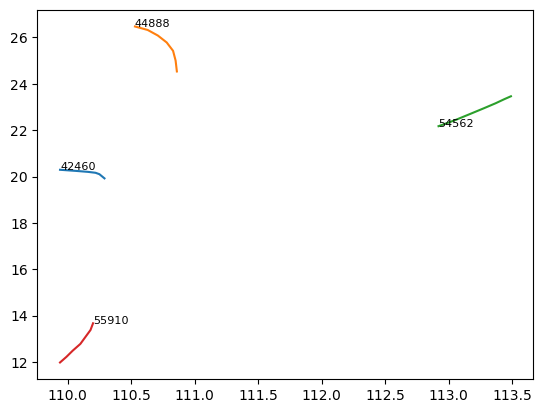

In [ ]:
for player, group in play_df.groupby("nfl_id"):
    plt.plot(group["x"], group["y"], label=player)
    plt.text(group["x"].iloc[0], group["y"].iloc[0], player, fontsize=8)